Loading dataset...
Class Distribution:
Class
0    97.86
1     2.14
Name: proportion, dtype: float64


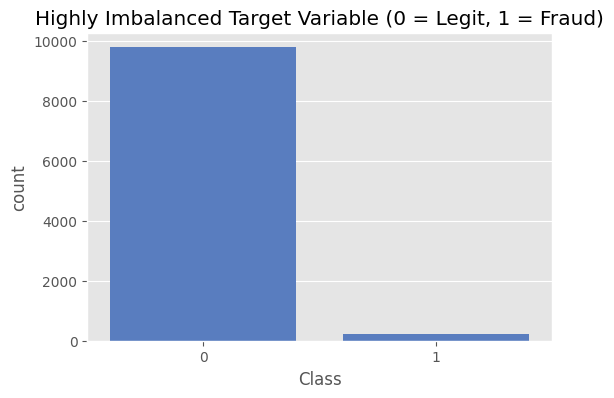

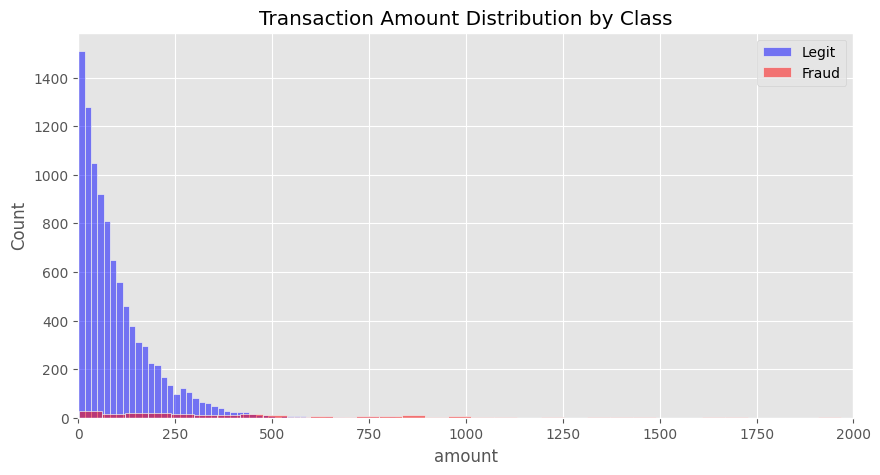

In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling
plt.style.use('ggplot')
sns.set_palette("muted")

# 2. Load the Dataset
# (Assuming you are using a dataset like the Kaggle Credit Card dataset)
print("Loading dataset...")
# df = pd.read_csv('../data/creditcard.csv') 
# For demonstration, we will generate a synthetic sample matching our schema:
np.random.seed(42)
n_samples = 10000
df = pd.DataFrame({
    'amount': np.random.exponential(scale=100, size=n_samples),
    'hour_of_day': np.random.randint(0, 24, n_samples),
    'Class': np.random.choice([0, 1], p=[0.98, 0.02], size=n_samples) # 2% fraud rate
})
# Inflate fraud amounts to simulate real-world theft
df.loc[df['Class'] == 1, 'amount'] = df.loc[df['Class'] == 1, 'amount'] * 5 

# 3. Class Imbalance Analysis
print("Class Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class')
plt.title('Highly Imbalanced Target Variable (0 = Legit, 1 = Fraud)')
plt.show()

# 4. Feature Distribution: Transaction Amount
plt.figure(figsize=(10, 5))
sns.histplot(data=df[df['Class'] == 0], x='amount', color='blue', alpha=0.5, label='Legit', bins=50)
sns.histplot(data=df[df['Class'] == 1], x='amount', color='red', alpha=0.5, label='Fraud', bins=50)
plt.xlim(0, 2000)
plt.title('Transaction Amount Distribution by Class')
plt.legend()
plt.show()

In [2]:
df.to_csv('../data/raw_data.csv', index=False)